# Sensitivity analysis.

## Prepare the notebook.

### Autoreload

In [1]:
%reload_ext autoreload
%autoreload 2

### Import Libraries.

In [2]:
import logging
import sys
import os
import yaml
from typing import Any

import matplotlib.pyplot as plt
import omegaconf
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm import tqdm
import torch
from scipy.special import softmax
from sklearn.preprocessing import LabelEncoder

from labcompass.utils import set_reproducibility
from labcompass.constants import DataFields, PredictionFields


### Define paths and constants.

In [3]:
BASE_DIR = "../../../.."
# PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH = "../../../../project_folder/dumps/2025-12-14_11-53-04/cerulean-durian-19_FlowMatching.pkl"
PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH = "../../../../project_folder/output/checkpoints/conditional_model/flow_matching/2026-02-11_20-04-08/neat-violet-213_FlowMatching.pkl"
TARGET_PREDICTION_MODEL_CHECKPOINT_PATH = "../../../../project_folder/dumps/2025-11-14_21-22-45/dashing-frog-1258_TargetPredictionModel.pkl"
TARGET_PREDICTION_MODEL_CHECKPOINT_PATH = "../../../../project_folder/output/checkpoints/cell_type_classifier/2025-11-14_21-22-45/dashing-frog-1258_TargetPredictionModel.pkl"
# PRIOR_FLOW_CHECKPOINT_PATH = "../../../../project_folder/prior_flow_FlowMatching.pkl"
PRIOR_FLOW_CHECKPOINT_PATH = "../../../../project_folder/output/checkpoints/prior/flow_matching/prior_flow_FlowMatching.pkl"
ANNOTATION_CONFIG_PATH = "../../../../inverse/loss_guidance/config/annotation/default.yaml"
# RESULTS_DIR = "../../../../project_folder/results_dir/results_new-masked"
RESULTS_DIR = "../../../../project_folder/output/inverse/loss_guidance/raw_data/penalized_oxy_days-pure_populations-reciprocal"

RANDOM_SEED = 42


### Import additional modules.

In [4]:
sys.path.insert(0, f"{BASE_DIR}/shared_utils")
from experiment_utils import get_forward_model

### Read annotation configurations.

In [5]:
with open(ANNOTATION_CONFIG_PATH, "r") as fb:
    annotation_dict = yaml.safe_load(fb)

### Retrieve scatter columns.

In [6]:
scatter_columns = annotation_dict["scatter_columns"]
n_scatter_feats = len(scatter_columns)
print(f"{n_scatter_feats=}")

n_scatter_feats=6


### Set seed for reproducibility.

In [7]:
set_reproducibility(RANDOM_SEED)

### Prepare configuration to load forward model.

In [8]:
config = omegaconf.DictConfig(
    {
        "paths": {
            "ct_classifier_path": TARGET_PREDICTION_MODEL_CHECKPOINT_PATH,
            "perturbation_prediction_path": PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH
        }
    }
)
config.paths

{'ct_classifier_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/2025-11-14_21-22-45/dashing-frog-1258_TargetPredictionModel.pkl', 'perturbation_prediction_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-02-11_20-04-08/neat-violet-213_FlowMatching.pkl'}

### Define utility function.

In [9]:
def query_forward_model(
    samples: np.ndarray,
    noise: np.ndarray,
    forward_model,
    num_time_steps: int,
    solver_kwargs: dict[str, Any],
    le_ct: LabelEncoder,
    n_scatter_feats: int = 6,
    logger: logging.Logger | None = None
):
    # prepare condition data
    perturbation_reps = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
    ccondition_data = torch.from_numpy(samples).float().to(forward_model.forward_model.device)
    ccondition_dict = {
        perturbation_reps: ccondition_data.unsqueeze(1).repeat(1, noise.shape[1], 1),
    }

    # construct batch dictionary
    batch_dict = {
        DataFields.PERTURBATION_DATA: ccondition_dict,
        DataFields.SOURCE_STATE: noise
    }

    # query forward model
    cforward_out = forward_model.predict(
        batch_dict,
        return_trajectory=False,
        no_grad=True,
        num_time_steps=num_time_steps,
        solver_kwargs=solver_kwargs,
        fix_noise=True,
    )
    X_gen = cforward_out[PredictionFields.PREDICTION_DATA].detach().cpu().numpy()
    gen_ct_logits = cforward_out[PredictionFields.TARGET_PREDICTION_DATA]["cell_type"].detach().cpu().numpy()

    # split channel and scatter features
    X_channel_gen = X_gen[..., :-n_scatter_feats]
    X_scatter_gen = X_gen[..., -n_scatter_feats:]

    # compute cell type probabilities and labels
    gen_ct_probs = softmax(gen_ct_logits, axis=-1)
    gen_ct_id_label = gen_ct_probs.argmax(-1)
    gen_ct_label = le_ct.inverse_transform(gen_ct_id_label.reshape(-1)).\
        reshape(gen_ct_id_label.shape[0], gen_ct_id_label.shape[1])
    if logger is not None:
        logger.info(f"{X_gen.shape=}, {X_channel_gen.shape=}, {X_scatter_gen.shape=}, {gen_ct_logits.shape=} {gen_ct_id_label.shape=}, {gen_ct_label.shape=}")
    return {
        "X": X_gen,
        "X_channel": X_channel_gen,
        "X_scatter": X_scatter_gen,
        "ct_logits": gen_ct_logits,
        "ct_probs": gen_ct_probs,
    }


## Prepare models and data.

### Load models.

In [10]:
forward_model, (
    perturbation_response_prediction_model,
    target_prediction_model
) = get_forward_model(
    config
)

### Retrieve data from target prediction model.

In [11]:
train_adata_g = target_prediction_model.train_data.adata
val_adata_g = target_prediction_model.validation_data.adata
adata_g = sc.concat((train_adata_g, val_adata_g), uns_merge="same")
print(f"{train_adata_g=}\n{val_adata_g=}\n{adata_g=}")


train_adata_g=AnnData object with n_obs × n_vars = 70000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'pca', 'X_scatter_params', 'X_channel_params'
   

### Retrieve data from perturbation response prediction model.

In [12]:
train_adata_phi = perturbation_response_prediction_model.train_data.adata
val_adata_phi = perturbation_response_prediction_model.validation_data[0].adata
print(f"{train_adata_phi=}\n{val_adata_phi=}")

n_train_cells = 70_000
n_val_cells = 30_000
train_adata_phi = sc.pp.sample(
    train_adata_phi,
    n=n_train_cells,
    copy=True
)
val_adata_phi = sc.pp.sample(
    val_adata_phi,
    n=n_val_cells,
    copy=True
)
print(f"{train_adata_phi=}\n{val_adata_phi=}")
adata_phi = sc.concat((train_adata_phi, val_adata_phi), uns_merge="same")
sc.pp.pca(adata_phi)
sc.pp.neighbors(adata_phi)
sc.tl.umap(adata_phi)
print(f"{adata_phi=}")

train_adata_phi=AnnData object with n_obs × n_vars = 92953367 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 'sr1_[nm]_one_hot', 'um171_[nm]_one_hot', 'um729_[µm]_one_ho

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


adata_phi=AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    uns: 'meta', 'processing_steps', 'one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 'sr1_[nm]_one_hot', 'um171_[nm]_one_hot', 'um729_[µm]_one_hot', 'scf_[ng_ml]_one_hot', 'butyzamide_[nm]_one_hot', 'retinoic_acid_[µm]_one_hot', 'ldl_[ng_ml]_one_hot', 'i

### Retrieve unique conditions.

In [13]:
conc_unique = np.unique(adata_phi.obsm["condition_concat"], axis=0)
conc_ubound = np.max(adata_phi.obsm["condition_concat"], axis=0)
conc_lbound = np.min(adata_phi.obsm["condition_concat"], axis=0)
print(f"{conc_unique.shape=}, {conc_ubound.shape=}, {conc_lbound.shape=}")

conc_unique.shape=(116, 12), conc_ubound.shape=(12,), conc_lbound.shape=(12,)


### Fit label encoder.

In [14]:
le_ct = LabelEncoder().fit(adata_g.obs["cell_type"])
le_ct

LabelEncoder()

## Load inverse results.

### Load results.

In [15]:
ct_results_dict = {}
ct_list = os.listdir(RESULTS_DIR)
pbar = tqdm(range(len(ct_list)))
for ct in ct_list:
    ct_dir = os.path.join(RESULTS_DIR, ct)
    if not os.path.isdir(ct_dir):
        pbar.update()
        continue
    ct_runs =  os.listdir(ct_dir)
    runs_dict = {}
    pbar.set_description(f"Reading results for {ct}, {len(ct_runs)} runs found")
    pbar.update()
    for run in ct_runs:
        run_dir = os.path.join(ct_dir, run)
        if not os.path.isdir(run_dir):
            continue
        inverse_results = np.load(
            os.path.join(run_dir, "inverse_results.npz")
        )
        fwd_results = np.load(
            os.path.join(run_dir, "fwd_results.npz")
        )
        with open(
            os.path.join(run_dir, "config.yaml"), "r"
        ) as fp:
            run_config = yaml.safe_load(fp)
        runs_dict[run] = {
            "inverse_results": inverse_results,
            "fwd_results": fwd_results,
            "config": run_config,
        }
    ct_results_dict[ct] = runs_dict

Reading results for EosBasoMastPre, 9 runs found: 100%|██████████| 10/10 [00:10<00:00,  1.21s/it]     

### Select run with best median loss for each cell type.

In [16]:
selected_runs = {}
for ct, results_dict in ct_results_dict.items():
    best_median_val = np.inf
    for run, run_dict in results_dict.items():
        loss = run_dict["inverse_results"]["loss_history"][..., -1]
        median_val = np.median(loss)
        if median_val < best_median_val:
            best_median_val = median_val
            best_run = run
    selected_runs[ct] = results_dict[best_run]

## Local Sensitivity Analysis.

### Utility function to create grid around samples.

In [17]:
def get_sample_grid_per_dim(samples, dim, n_steps=5, lbound=None, ubound=None):
    nperturbed = []
    pperturbed = []
    if lbound is not None and ubound is not None:
        pert_arr = np.linspace(lbound, ubound, num=n_steps*2)
    else:
        pert_arr = np.array(
            [samples[dim] - (step/n_steps)*samples[dim] for step in range(1, n_steps + 1)] + \
            [samples[dim] + (step/n_steps)*samples[dim] for step in range(1, n_steps + 1)]
        )
    for step in range(1, n_steps + 1):
        nperturbed_sample = samples.copy()
        pperturbed_sample = samples.copy()
        nperturbed_sample[..., dim] = pert_arr[step]
        pperturbed_sample[..., dim] = pert_arr[-step]
        pperturbed.append(pperturbed_sample)
        nperturbed.append(nperturbed_sample)
    return np.stack(
        nperturbed + pperturbed, axis=0
    )

def get_sample_grid(samples, n_steps=5, lbound=None, ubound=None):
    perturbed = []
    for dim in range(samples.shape[-1]):
        dim_lbound = lbound[dim] if lbound is not None else None
        dim_ubound = ubound[dim] if ubound is not None else None
        grid = get_sample_grid_per_dim(samples, dim, n_steps=n_steps, lbound=dim_lbound, ubound=dim_ubound)
        perturbed.append(grid)
    return np.stack(perturbed, axis=0)

### Create evaluation grid for each of the sample by perturbing around each value.

In [18]:
# n_steps = 5
# ct2sensitivity_grid = {}
# for ct, runs_dict in selected_runs.items():
#     samples = np.maximum(0, runs_dict["inverse_results"]["trajectory"][:, -1, :])
#     sample_grid = get_sample_grid(samples, n_steps=n_steps)
#     noise = runs_dict["inverse_results"]["noise"]
#     ct2sensitivity_grid[ct] = {"grid": sample_grid, "noise": noise}
# ct2sensitivity_grid.keys()

### Create evaluation grid for each of the sample from bounds by data.

In [23]:
n_steps = 5
ct2sensitivity_grid = {}
for ct, runs_dict in selected_runs.items():
    samples = np.maximum(0, runs_dict["inverse_results"]["trajectory"][:, -1, :])
    # best_run_idx = runs_dict["inverse_results"]["loss_history"][-1].argmin()
    # sample_best_run = samples[best_run_idx][None]
    # sample_grid = get_sample_grid(sample_best_run, n_steps=n_steps, lbound=conc_lbound, ubound=conc_ubound)
    sample_grid = get_sample_grid(samples, n_steps=n_steps, lbound=conc_lbound, ubound=conc_ubound)
    noise = runs_dict["inverse_results"]["noise"]
    ct2sensitivity_grid[ct] = {"grid": sample_grid, "noise": noise}
ct2sensitivity_grid.keys()

dict_keys(['DCs-CD14', 'EryPro', 'GMP-Neutro:CD16-Mono', 'Early_Pro-B', 'CyclingProgenitor*', 'Pro-B', 'CD14-Mono', 'MgkPro', 'HSCs', 'EosBasoMastPre'])

### Querying forward model for each point on the grid.

In [25]:
n_tims_steps=50
solver_kwargs={"method":"euler"}

sensitivity_eval_results = {}

pbar = tqdm(
    range(
        len(ct2sensitivity_grid) * len(annotation_dict["protocol_columns"]) * n_steps*2
    )
)

for ct, ct_dict in ct2sensitivity_grid.items():
    noise = torch.from_numpy(ct_dict["noise"]).float().cuda()
    sample_grid = ct_dict["grid"]
    ct_res = {}
    for perturbed_ax in range(sample_grid.shape[0]):
        ax_grid = sample_grid[perturbed_ax]
        ax_res = {}
        for grid_val in range(ax_grid.shape[0]):
            pbar.set_description(f"{ct}:a{perturbed_ax}:s{grid_val}")
            pbar.update()
            val = ax_grid[grid_val]
            fwd_results = query_forward_model(
                val,
                noise,
                forward_model,
                n_tims_steps,
                solver_kwargs,
                le_ct
            )
            fwd_results["mean_probs"] = fwd_results["ct_probs"].mean(1)
            ax_res[grid_val] = fwd_results
        ct_res[perturbed_ax] = ax_res
    sensitivity_eval_results[ct] = ct_res


DCs-CD14:a0:s0:   0%|          | 1/1200 [00:15<5:17:34, 15.89s/it]


KeyboardInterrupt: 

In [31]:
sensitivity_eval_results.keys()

dict_keys([])

In [32]:
sensitivity_eval_results[ct] = ct_res

### Visualize results.

KeyError: 3

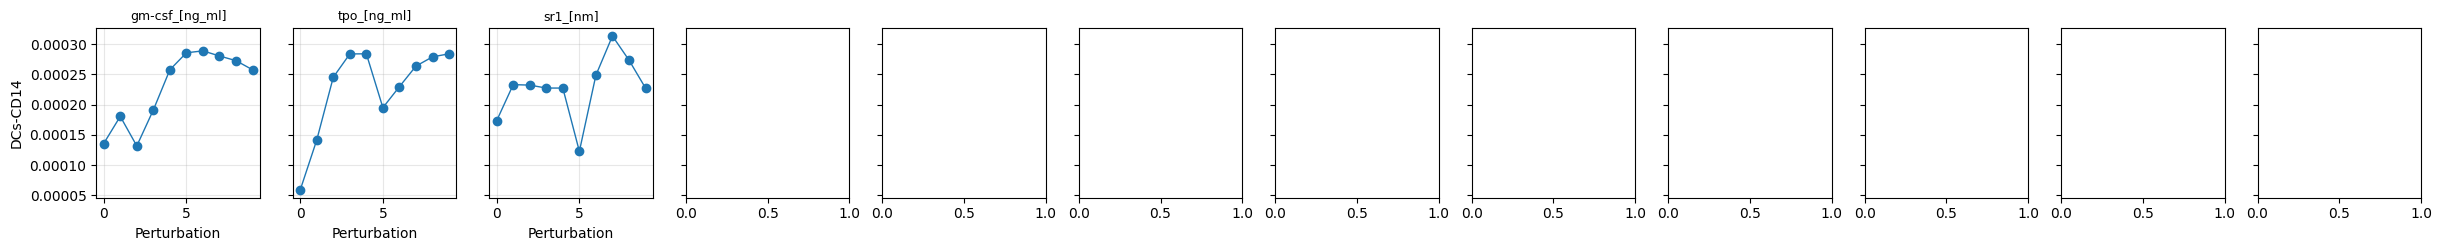

In [33]:
def plot_ct_axis_matrix(
    sensitivity_eval_results,
    cell_types,
    le_ct,
    protocol_cols,
):
    n_rows = len(cell_types)
    n_cols = len(protocol_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.5 * n_cols, 2.2 * n_rows),
        sharey="row"
    )

    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for r, ct in enumerate(cell_types):
        ct_orig = ct.replace(":", "/")
        ct_index = le_ct.transform([ct_orig])[0]

        for c, ax_name in enumerate(protocol_cols):
            ax_plot = axes[r, c]

            ax_dict = sensitivity_eval_results[ct][c]
            gids = sorted(ax_dict.keys())


            vals = np.stack(
                # [ax_dict[gid]["mean_probs"][:, ct_index] for gid in gids],
                [ax_dict[gid]["mean_probs"][50, ct_index][None] for gid in gids],
                axis=0
            )

            mean_curve = vals#.mean(axis=1)

            ax_plot.plot(gids, mean_curve, marker="o", linewidth=1)

            if r == 0:
                ax_plot.set_title(ax_name, fontsize=9)

            if c == 0:
                ax_plot.set_ylabel(ct)

            if r == n_rows - 1:
                ax_plot.set_xlabel("Perturbation")

            ax_plot.grid(True, alpha=0.3)

    fig.suptitle("Cell-type × Axis sensitivity", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_ct_axis_matrix(
    sensitivity_eval_results,
    cell_types=list(sensitivity_eval_results.keys()),
    # cell_types=['EryPro', 'Early_Pro-B'],
    le_ct=le_ct,
    protocol_cols=annotation_dict["protocol_columns"],
)